In [ ]:
# Cancer Type Classification from RNA-Seq Gene Expression Data using Machine Learning

## Objective

The objective of this project is to develop an end-to-end machine learning pipeline to classify different cancer types based on gene expression patterns obtained from RNA-Seq data.

Multiple supervised machine learning algorithms are implemented and compared to identify their effectiveness in cancer type classification.

---

## Dataset

**Source:** Kaggle - Gene Expression Cancer RNA-Seq Dataset  
**Original Source:** UCI Machine Learning Repository

This dataset contains RNA-Seq gene expression profiles collected from cancer samples. Each sample contains expression values of thousands of genes, which can be used to identify and classify different cancer types.

### Dataset Characteristics:

- **Input Features (X):** Expression levels of 20,530 genes
- **Target Variable (y):** Cancer type
- **Machine Learning Task:** Multi-class classification
- **Number of Cancer Classes:** 5

The goal is to build machine learning models capable of accurately predicting the cancer type based on gene expression patterns.

---

## Tech Stack

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost

---

## Machine Learning Models Used

The following classification algorithms were trained and evaluated:

- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest Classifier
- XGBoost Classifier

---

## Evaluation Metrics

The models were evaluated using:

- Accuracy Score
- Classification Report (Precision, Recall, F1-score)
- Confusion Matrix
- Cross-validation Score

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


In [2]:
X=pd.read_csv('data.csv')
y=pd.read_csv('labels.csv')

In [3]:
X.head()

,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


In [4]:
y.head()

,Unnamed: 0,Class
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD
3,sample_3,PRAD
4,sample_4,BRCA


In [5]:
X=X.rename(columns={'Unnamed: 0':'id'})
y=y.rename(columns={'Unnamed: 0':'id','Class':'label'})

In [6]:
df=X.merge(y,on='id')

In [7]:
df.head()

,id,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,label
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0,PRAD
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0,LUAD
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0,PRAD
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0,PRAD
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0,BRCA


In [8]:
df.describe()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
count,801.000000,801.000000,801.000000,801.000000,801.000000,801.0,801.000000,801.000000,801.000000,801.000000,...,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000
mean,0.026642,3.010909,3.095350,6.722305,9.813612,0.0,7.405509,0.499882,0.016744,0.013428,...,5.896573,8.765891,10.056252,4.847727,9.741987,11.742228,10.155271,9.590726,5.528177,0.095411
std,0.136850,1.200828,1.065601,0.638819,0.506537,0.0,1.108237,0.508799,0.133635,0.204722,...,0.746399,0.603176,0.379278,2.382728,0.533898,0.670371,0.580569,0.563849,2.073859,0.364529
min,0.000000,0.000000,0.000000,5.009284,8.435999,0.0,3.930747,0.000000,0.000000,0.000000,...,2.853517,6.678368,8.669456,0.000000,7.974942,9.045255,7.530141,7.864533,0.593975,0.000000
25%,0.000000,2.299039,2.390365,6.303346,9.464466,0.0,6.676042,0.000000,0.000000,0.000000,...,5.454926,8.383834,9.826027,3.130750,9.400747,11.315857,9.836525,9.244219,4.092385,0.000000
50%,0.000000,3.143687,3.127006,6.655893,9.791599,0.0,7.450114,0.443076,0.000000,0.000000,...,5.972582,8.784144,10.066385,5.444935,9.784524,11.749802,10.191207,9.566511,5.218618,0.000000
75%,0.000000,3.883484,3.802534,7.038447,10.142324,0.0,8.121984,0.789354,0.000000,0.000000,...,6.411292,9.147136,10.299025,6.637412,10.082269,12.177852,10.578561,9.917888,6.876382,0.000000
max,1.482332,6.237034,6.063484,10.129528,11.355621,0.0,10.718190,2.779008,1.785592,4.067604,...,7.771054,11.105431,11.318243,9.207495,11.811632,13.715361,11.675653,12.813320,11.205836,5.254133


In [9]:
df.isnull().sum()


id            0
gene_0        0
gene_1        0
gene_2        0
gene_3        0
             ..
gene_20527    0
gene_20528    0
gene_20529    0
gene_20530    0
label         0
Length: 20533, dtype: int64

In [10]:
print(df.dtypes)

id             object
gene_0        float64
gene_1        float64
gene_2        float64
gene_3        float64
               ...   
gene_20527    float64
gene_20528    float64
gene_20529    float64
gene_20530    float64
label          object
Length: 20533, dtype: object


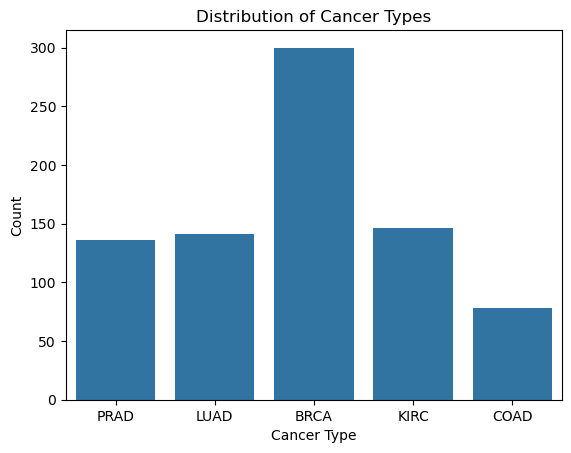

In [11]:
sns.countplot(data=y,x='label')
plt.xlabel('Cancer Type')
plt.ylabel('Count')
plt.title('Distribution of Cancer Types')
plt.show()

In [12]:
X=X.drop('id',axis=1,errors='ignore')
y=y.drop('id',axis=1,errors='ignore')

In [13]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

c:\Users\Hafees\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Hafees\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [16]:
from sklearn.linear_model import LogisticRegression

clf=LogisticRegression()


clf.fit(X_train, y_train_encoded)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
y_pred=clf.predict(X_test)

In [18]:
y_pred

array([3, 0, 3, 2, 0, 0, 0, 1, 4, 3, 1, 0, 3, 4, 2, 3, 3, 4, 0, 3, 3, 1,
       2, 0, 0, 0, 1, 0, 4, 4, 0, 4, 4, 1, 0, 0, 3, 0, 3, 0, 1, 0, 0, 0,
       2, 4, 2, 1, 0, 0, 4, 3, 2, 0, 2, 0, 2, 0, 3, 3, 3, 2, 4, 0, 4, 0,
       3, 4, 2, 0, 0, 3, 0, 0, 0, 3, 4, 4, 2, 0, 2])

In [19]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

print("Accuracy score: ", accuracy_score(y_test_encoded,y_pred))

print("\nClassification Report: ")
print(classification_report(y_test_encoded,y_pred))

print("\nConfusion Matrix: ")
print(confusion_matrix(y_test_encoded,y_pred))

Accuracy score:  1.0

Classification Report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00        12
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        14

    accuracy                           1.00        81
   macro avg       1.00      1.00      1.00        81
weighted avg       1.00      1.00      1.00        81


Confusion Matrix: 
[[31  0  0  0  0]
 [ 0  7  0  0  0]
 [ 0  0 12  0  0]
 [ 0  0  0 17  0]
 [ 0  0  0  0 14]]


In [20]:
from sklearn.model_selection import cross_val_score

y_cv = y.values.ravel()

scores = cross_val_score(
    LogisticRegression(max_iter=5000),X,y_cv,cv=5)

print(scores)
print("Mean:", scores.mean())

[0.98757764 1.         1.         1.         1.        ]
Mean: 0.9975155279503106


In [21]:
from sklearn.svm import SVC

svm=SVC(kernel='linear')

svm.fit(X_train,y_train_encoded)

y_pred_svm=svm.predict(X_test)

In [22]:
print("SVM Accuracy:", accuracy_score(y_test_encoded, y_pred_svm))

print(classification_report(y_test_encoded, y_pred_svm))

SVM Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00        12
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        14

    accuracy                           1.00        81
   macro avg       1.00      1.00      1.00        81
weighted avg       1.00      1.00      1.00        81



In [23]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=200,random_state=42)

rf.fit(X_train,y_train_encoded)

y_pred_rf=rf.predict(X_test)

In [24]:
print("Random Forest Accuracy:", accuracy_score(y_test_encoded, y_pred_rf))

print(classification_report(y_test_encoded, y_pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00        12
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        14

    accuracy                           1.00        81
   macro avg       1.00      1.00      1.00        81
weighted avg       1.00      1.00      1.00        81



In [25]:
import xgboost
from xgboost import XGBClassifier

xgb=XGBClassifier(random_state=42)

xgb.fit(X_train,y_train_encoded)

y_pred_xgb=xgb.predict(X_test)

In [26]:
print("XGBoost accuracy:", accuracy_score(y_test_encoded, y_pred_rf))

print(classification_report(y_test_encoded, y_pred_xgb))

XGBoost accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00        12
           3       1.00      1.00      1.00        17
           4       1.00      1.00      1.00        14

    accuracy                           1.00        81
   macro avg       1.00      1.00      1.00        81
weighted avg       1.00      1.00      1.00        81



In [27]:
results = {
    "Logistic Regression": accuracy_score(y_test_encoded, y_pred),
    "SVM": accuracy_score(y_test_encoded, y_pred_svm),
    "Random Forest": accuracy_score(y_test_encoded, y_pred_rf),
    "XGBoost": accuracy_score(y_test_encoded, y_pred_xgb)
}

print(results)

{'Logistic Regression': 1.0, 'SVM': 1.0, 'Random Forest': 1.0, 'XGBoost': 1.0}
